In [43]:
import pandas as pd 
import numpy as np 

In [44]:
df = pd.read_csv("credit_risk_cleaned.csv")
print(df.shape)

(51336, 88)


In [45]:
df.info

<bound method DataFrame.info of        PROSPECTID  Total_TL  Tot_Closed_TL  Tot_Active_TL  \
0               1         5              4              1   
1               2         1              0              1   
2               3         8              0              8   
3               4         1              0              1   
4               5         3              2              1   
...           ...       ...            ...            ...   
51331       51332         3              0              3   
51332       51333         4              2              2   
51333       51334         2              1              1   
51334       51335         2              1              1   
51335       51336         1              0              1   

       Total_TL_opened_L6M  Tot_TL_closed_L6M  pct_tl_open_L6M  \
0                        0                  0            0.000   
1                        0                  0            0.000   
2                        1           

In [46]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PROSPECTID,51336.0,NaN,NaN,NaN,25668.5,14819.571046,1.0,12834.75,25668.5,38502.25,51336.0
Total_TL,51336.0,NaN,NaN,NaN,4.858598,7.177116,1.0,1.0,2.0,5.0,235.0
Tot_Closed_TL,51336.0,NaN,NaN,NaN,2.770415,5.94168,0.0,0.0,1.0,3.0,216.0
Tot_Active_TL,51336.0,NaN,NaN,NaN,2.088184,2.290774,0.0,1.0,1.0,3.0,47.0
Total_TL_opened_L6M,51336.0,NaN,NaN,NaN,0.736754,1.296717,0.0,0.0,0.0,1.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...
last_prod_enq2,51336,6,others,20831,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_prod_enq2,51336,6,others,28120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit_Score,51336.0,NaN,NaN,NaN,679.859222,20.502764,469.0,669.0,680.0,691.0,811.0
Approved_Flag,51336,4,P2,32199,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
df.isna().sum().sort_values(ascending = False)

CC_utilization                  47636
PL_utilization                  44435
time_since_recent_deliquency    35949
time_since_first_deliquency     35949
max_delinquency_level           35949
                                ...  
last_prod_enq2                      0
first_prod_enq2                     0
Credit_Score                        0
Approved_Flag                       0
Log_Income                          0
Length: 88, dtype: int64

In [48]:
# Gender, Marital Status, Education are categorical variables. 
# We will convert them to numerical variables using encoding.

# last_prod_enq2 = Lates product enquired for 
# first_prod_enq2 = First productd enquired for

# ^ These are also categorical variables. We will convert them to numerical variables using encoding.

In [49]:
categorical_cols = df.select_dtypes(include=["object"]).columns

numerical_cols = df.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical Columns:", len(numerical_cols))

Categorical Columns:
['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2', 'first_prod_enq2', 'Approved_Flag']

Number of categorical columns: 6

Numerical Columns: 82


C:\Users\Aditi\AppData\Local\Temp\ipykernel_22180\3294498339.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [50]:
categorical_cols = [
    "MARITALSTATUS",
    "EDUCATION",
    "GENDER",
    "last_prod_enq2",
    "first_prod_enq2"
]

for col in categorical_cols:
    print("=" * 50)
    print(col)
    print(df[col].value_counts())

MARITALSTATUS
MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64
EDUCATION
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64
GENDER
GENDER
M    45245
F     6091
Name: count, dtype: int64
last_prod_enq2
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64
first_prod_enq2
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64


In [51]:
df["GENDER"] = df["GENDER"].map({
    "M": 1,
    "F": 0
})

df["MARITALSTATUS"] = df["MARITALSTATUS"].map({
    "Married": 1,
    "Single": 0
})

In [52]:
df = pd.get_dummies(
    df,
    columns=[
        "EDUCATION",
        "last_prod_enq2",
        "first_prod_enq2"
    ],
    drop_first=True,
    dtype=int
)

In [53]:
target_mapping = {
    "P1": 0,
    "P2": 1,
    "P3": 2,
    "P4": 3
}

df["Approved_Flag"] = df["Approved_Flag"].map(target_mapping)

In [54]:
print(df.shape)

print("\nRemaining categorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

(51336, 101)

Remaining categorical columns:
[]


In [55]:
X = df.drop(columns=["Approved_Flag"])
y = df["Approved_Flag"]

## Train-Test Split

The dataset is split into training (80%) and testing (20%) sets. We use stratified sampling to preserve the distribution of the target classes (`Approved_Flag`) in both subsets. Feature selection and model training will be performed only on the training set to prevent data leakage.

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Approved_Flag"])
y = df["Approved_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(41068, 100)
(10268, 100)


In [57]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)

selected_features = X_train.columns[selector.get_support()]

print(f"Original Features: {X_train.shape[1]}")
print(f"Selected Features: {len(selected_features)}")

Original Features: 100
Selected Features: 96


In [58]:
removed_features = X_train.columns[~selector.get_support()]

print("Removed Features:")
print(removed_features.tolist())

Removed Features:
['num_sub_6mts', 'num_dbt_6mts', 'num_lss_6mts', 'EDUCATION_PROFESSIONAL']


In [59]:
corr_matrix = X_train.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Highly Correlated Features:")
print(to_drop)

Highly Correlated Features:
['Tot_Closed_TL', 'pct_closed_tl', 'Secured_TL', 'Age_Newest_TL', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std_12mts', 'num_dbt_12mts', 'num_lss_12mts', 'PL_enq_L12m', 'enq_L6m', 'pct_of_active_TLs_ever', 'CC_utilization', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever']


In [60]:
X_train.isna().sum().sort_values(ascending=False)

CC_utilization                  38148
PL_utilization                  35591
max_delinquency_level           28811
time_since_first_deliquency     28811
time_since_recent_deliquency    28811
                                ...  
first_prod_enq2_CC                  0
first_prod_enq2_ConsumerLoan        0
first_prod_enq2_HL                  0
first_prod_enq2_PL                  0
first_prod_enq2_others              0
Length: 100, dtype: int64

In [61]:
X_train_mi = X_train.copy()

In [62]:
X_train_mi = X_train_mi.fillna(-999)

In [65]:
from sklearn.feature_selection import mutual_info_classif


mi_scores = mutual_info_classif(
    X_train_mi,
    y_train,
    random_state=42
)

In [67]:
mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
).sort_values(ascending=False)

In [68]:
mi_scores.head(20)

Credit_Score              1.058296
enq_L3m                   0.184364
enq_L6m                   0.151128
Age_Oldest_TL             0.137340
time_since_recent_enq     0.128238
enq_L12m                  0.122224
PL_enq_L6m                0.089305
num_std                   0.089071
num_std_12mts             0.083070
pct_PL_enq_L6m_of_ever    0.080805
pct_PL_enq_L6m_of_L12m    0.077048
tot_enq                   0.075430
num_std_6mts              0.072648
PL_enq_L12m               0.070675
pct_tl_open_L12M          0.064044
Secured_TL                0.051366
pct_of_active_TLs_ever    0.048925
pct_tl_open_L6M           0.046999
pct_active_tl             0.046685
Total_TL                  0.045106
dtype: float64

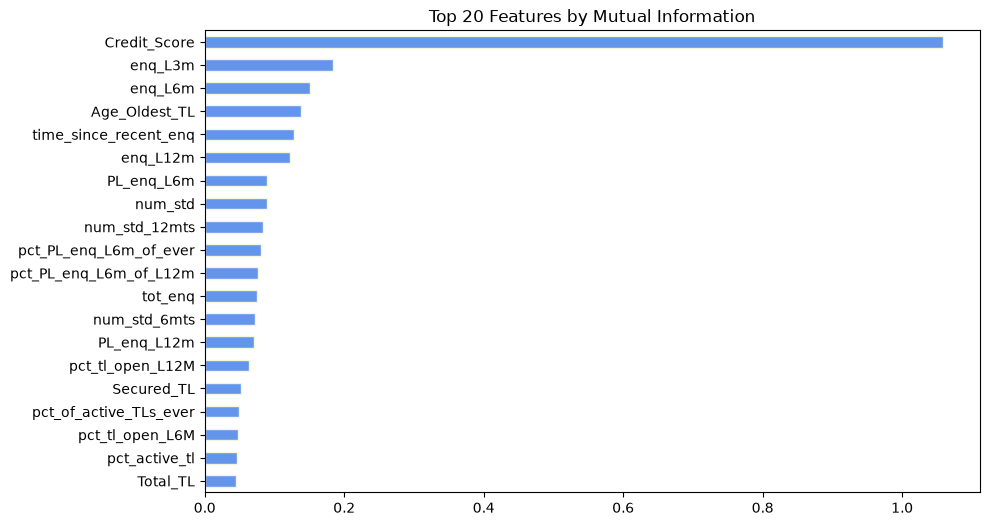

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

mi_scores.head(20).sort_values().plot(kind="barh",color="cornflowerblue", edgecolor="beige")

plt.title("Top 20 Features by Mutual Information")

plt.show()

In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(20)

Credit_Score                    0.458019
Age_Oldest_TL                   0.057892
enq_L3m                         0.045165
time_since_recent_enq           0.030399
enq_L6m                         0.024424
num_std                         0.021158
num_std_12mts                   0.018029
num_std_6mts                    0.016220
enq_L12m                        0.015311
time_since_recent_deliquency    0.013298
time_since_recent_payment       0.010782
pct_PL_enq_L6m_of_ever          0.010728
Total_TL                        0.010339
tot_enq                         0.009966
pct_PL_enq_L6m_of_L12m          0.009681
PROSPECTID                      0.009334
PL_enq_L6m                      0.009122
AGE                             0.009054
Time_With_Curr_Empr             0.008439
recent_level_of_deliq           0.008367
dtype: float64

In [77]:
X_train = X_train.drop(columns=["PROSPECTID"])
X_test = X_test.drop(columns=["PROSPECTID"])

In [78]:
low_variance = [
    "num_sub_6mts",
    "num_dbt_6mts",
    "num_lss_6mts",
    "EDUCATION_PROFESSIONAL"
]

X_train = X_train.drop(columns=low_variance)
X_test = X_test.drop(columns=low_variance)

In [79]:
high_corr = [
    "pct_closed_tl",
    "pct_of_active_TLs_ever",
    "pct_PL_enq_L6m_of_ever",
    "pct_CC_enq_L6m_of_ever"
]

X_train = X_train.drop(columns=high_corr)
X_test = X_test.drop(columns=high_corr)

In [80]:
feature_scores = pd.DataFrame({
    "Mutual Information": mi_scores,
    "Random Forest": importance
})

feature_scores

,Mutual Information,Random Forest
AGE,0.035779,0.009054
Age_Newest_TL,0.019842,0.008255
Age_Oldest_TL,0.137340,0.057892
Auto_TL,0.014739,0.003222
CC_Flag,0.004601,0.000531
...,...,...
time_since_first_deliquency,0.033150,0.007781
time_since_recent_deliquency,0.038220,0.013298
time_since_recent_enq,0.128238,0.030399
time_since_recent_payment,0.009328,0.010782


In [81]:
feature_scores["Average Rank"] = (
    feature_scores["Mutual Information"].rank(ascending=False) +
    feature_scores["Random Forest"].rank(ascending=False)
) / 2

feature_scores.sort_values("Average Rank").head(30)

,Mutual Information,Random Forest,Average Rank
Credit_Score,1.058296,0.458019,1.0
enq_L3m,0.184364,0.045165,2.5
Age_Oldest_TL,0.137340,0.057892,3.0
enq_L6m,0.151128,0.024424,4.0
time_since_recent_enq,0.128238,0.030399,4.5
num_std,0.089071,0.021158,7.0
enq_L12m,0.122224,0.015311,7.5
num_std_12mts,0.083070,0.018029,8.0
num_std_6mts,0.072648,0.016220,10.5
pct_PL_enq_L6m_of_ever,0.080805,0.010728,11.0


## Feature Engineering Summary 😼😼

The following feature engineering steps were completed:

- Encoded categorical variables using One-Hot Encoding.
- Converted target labels (P1–P4) into numerical classes.
- Split the data into training and testing sets.
- Removed identifier columns (PROSPECTID).
- Removed near-zero variance features.
- Removed highly correlated features to reduce redundancy.
- Evaluated feature importance using:
    - Mutual Information
    - Random Forest Feature Importance

The processed dataset is now ready for model building.